# 3D example
This notebook shows a simple analysis pipeline for running and analyzing a 3D simulation with DISCO-DJ.

0.7.2
gpu
DiscoDJ
——————————
Name: 3D_analysis
Dimensions: 3D
Resolution: 256³ particles
Boxsize: 2500.0 Mpc/h
Precision: double
Device: gpu
Cosmology:
  Omega_c: 0.2610 
  Omega_b: 0.0489 
  Omega_de: 0.6900 
  h: 0.6774 
  n_s: 0.9682 
  sigma8: 0.8090 
  Omega_k: 0.0000 
  w0: -1.0000 
  wa: 0.0000 
  mnu: 0.0000 
sigma8 according to file: 0.5910, sigma8 according to cosmology: 0.8090. The value of sigma8 will be normalized to the cosmology.
DiscoDJ
——————————
Name: 3D_analysis
Dimensions: 3D
Resolution: 256³ particles
Boxsize: 2500.0 Mpc/h
Precision: double
Device: gpu
Cosmology:
  Omega_c: 0.2610 
  Omega_b: 0.0489 
  Omega_de: 0.6865 
  h: 0.6774 
  n_s: 0.9682 
  sigma8: 0.8090 
  Omega_k: 0.0000 
  w0: -1.0000 
  wa: 0.0000 
  mnu: 0.1500 
sigma8 according to file: 0.5739, sigma8 according to cosmology: 0.8090. The value of sigma8 will be normalized to the cosmology.
DiscoDJ
——————————
Name: 3D_analysis
Dimensions: 3D
Resolution: 256³ particles
Boxsize: 2500.0 Mpc/h
Precision: 

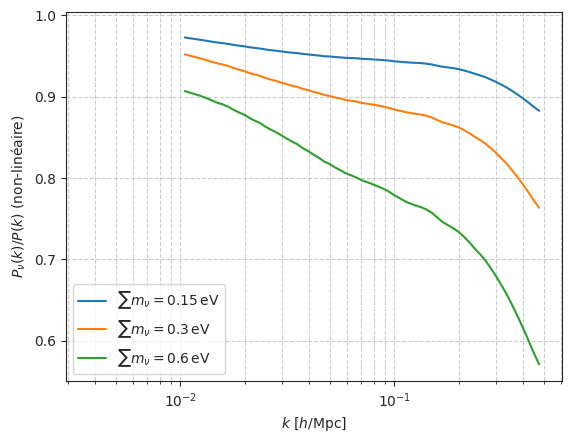

In [2]:
# Import modules
import os
from matplotlib import pyplot as plt
import matplotlib as mpl
%matplotlib inline
import seaborn as sns
sns.set_style("ticks")
import jax
from jax import config
import numpy as np
os.environ["USE_MASSIVE_NEUTRINOS"] = "0" #Def we use normal DISCO-DJ or Massive neutrinos version
from discodj import DiscoDJ
plt.rcParams['image.cmap'] = "rocket"
print(jax.__version__)

#from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
#mpl.use("pgf")
#mpl.rcParams.update({
#    "pgf.texsystem": "pdflatex",
#    "font.family": "serif",
#    "text.usetex": True,
#})

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
#os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95" # maximize available memory (might need to tune this in case you're running out of memory)

# Detect if a GPU is available
devices = jax.devices()
device = "gpu" if np.any([d.platform == "gpu" for d in devices]) else "cpu"
print(device)


# Set the parameters
name = "3D_analysis"
dim = 3

precision = "double"
if precision == "double":
    config.update("jax_enable_x64", True)


# Define the boxsize and resolution
boxsize = 2500  # in Mpc/h
res = 256  # the particles live on a Lagrangrian grid of resolution (res)^dim



###########################################################################################################################################################################

# The cosmology can be provided as a dictionary or a string for a pre-defined cosmology (e.g. "CamelsCV" for the Camels Cosmic Variance suite).
# cosmo = "CamelsCV"
cosmo = dict(Omega_c=0.2610089,  # cold dark matter content
             Omega_b=0.0488911,  # baryonic content (note: Disco-DJ so far only performs N-body simulations, no hydro; this is only used for the linear power spectrum!)
             h=0.67742,  # dimensionless Hubble constant
             n_s=0.96822,  # scalar spectral index
             sigma8=0.808992,  # amplitude of matter density fluctuations at a scale of 8 Mpc/h
             mnu = 0.0) #Neutrino mass (eV)
             
dj = DiscoDJ(dim=dim, res=res, name=name, device=device, precision=precision, boxsize=boxsize, cosmo=cosmo)
print(dj)
dj = dj.with_timetables()
#dj = dj.with_linear_ps(fix_sigma8=True, transfer_function="Eisenstein-Hu")
dj = dj.with_linear_ps(fix_sigma8=True, transfer_function="from_file", filename="Pk_cb_massless_z0.txt")
white_noise_field = dj.get_ngenic_noise(seed=13)  # a white noise field, defined in real space
dj = dj.with_ics(white_noise_space="real", white_noise_field=white_noise_field, convert_to_numpy=True)
k_pre, Pk_pre, _ = dj.evaluate_power_spectrum(dj.delta_ini, compute_std=False, bins=80)

n_order = 2
stepper = "bullfrog"
method = "pm"
res_pm = dj.res
time_var = "D"
antialias = 0
grad_kernel_order = 4
laplace_kernel_order = 0
worder = 2
n_resample = 1
deconvolve = False
nlpt_order_ics = n_order
chunk_size = None  # if you are running out of GPU memory, doing the mass assignment in smaller chunks might help (e.g. chunk_size = dj.res ** dj.dim // 16)
numsteps = 10  # number of steps to be performed
a_ini = 0.02  # initial scale factor of the simulation (where it is initialized with LPT)
a_end = 1.0  # final scale factor of the simulation
a_list = np.linspace(a_ini, a_end, numsteps, endpoint=False)

dj = dj.with_lpt(n_order=n_order, convert_to_numpy=True)  # convert_to_numpy as above; note that this breaks differentiability
X_sim, P_sim, a_sim = dj.run_nbody(a_ini=a_ini, a_end=a_end, n_steps=numsteps, res_pm=res_pm,
                                   time_var=time_var, stepper=stepper, method=method, antialias=antialias,
                                   grad_kernel_order=grad_kernel_order, laplace_kernel_order=laplace_kernel_order,
                                   nlpt_order_ics=nlpt_order_ics, n_resample=n_resample,
                                   deconvolve=deconvolve, return_displacement=False, chunk_size=chunk_size,
                                   convert_to_numpy=True)  # convert_to_numpy: same as above for the ICs and LPT
delta_sim = dj.get_delta_from_pos(X_sim, res= dj.res, n_resample=8)
k, Pk, _ = dj.evaluate_power_spectrum(delta_sim, bins=dj.res//3, deconvolve=True, worder=2)

###########################################################################################################################################################################
results_disco = []
for sum_masses in [0.15, 0.3, 0.6]:
    cosmo_nu = dict(Omega_c=0.2610089,  # cold dark matter content
                Omega_b=0.0488911,  # baryonic content (note: Disco-DJ so far only performs N-body simulations, no hydro; this is only used for the linear power spectrum!)
                h=0.67742,  # dimensionless Hubble constant
                n_s=0.96822,  # scalar spectral index
                sigma8=0.808992,  # amplitude of matter density fluctuations at a scale of 8 Mpc/h
                mnu = sum_masses) #Neutrino mass (eV)

    dj_nu = DiscoDJ(dim=dim, res=res, name=name, device=device, precision=precision, boxsize=boxsize, cosmo=cosmo_nu)
    print(dj_nu)
    dj_nu = dj_nu.with_timetables()
    #dj_nu = dj_nu.with_linear_ps(fix_sigma8=True, transfer_function="Eisenstein-Hu")
    dj_nu = dj_nu.with_linear_ps(fix_sigma8=True, transfer_function="from_file", filename=f"Pk_cb_sumMnu_{sum_masses:.2f}eV_z0.txt")
    dj_nu = dj_nu.with_ics(white_noise_space="real", white_noise_field=white_noise_field, convert_to_numpy=True)
    k_pre_nu, Pk_pre_nu, _ = dj_nu.evaluate_power_spectrum(dj.delta_ini, compute_std=False, bins=80)
    dj_nu = dj_nu.with_lpt(n_order=n_order, convert_to_numpy=True)  # convert_to_numpy as above; note that this breaks differentiability
    X_sim_nu, P_sim_nu, a_sim_nu = dj_nu.run_nbody(a_ini=a_ini, a_end=a_end, n_steps=numsteps, res_pm=res_pm,
                                    time_var=time_var, stepper=stepper, method=method, antialias=antialias,
                                    grad_kernel_order=grad_kernel_order, laplace_kernel_order=laplace_kernel_order,
                                    nlpt_order_ics=nlpt_order_ics, n_resample=n_resample,
                                    deconvolve=deconvolve, return_displacement=False, chunk_size=chunk_size,
                                    convert_to_numpy=True)  # convert_to_numpy: same as above for the ICs and LPT
    delta_sim_nu = dj_nu.get_delta_from_pos(X_sim_nu, res= dj.res, n_resample=8)
    k_nu, Pk_nu, _ = dj_nu.evaluate_power_spectrum(delta_sim_nu, bins=dj.res//3, deconvolve=True, worder=2)

    
    plt.figure(2)
    plt.semilogx(
        k_nu/0.67742,
        Pk_nu / Pk,
        label=fr"$\sum m_\nu = {sum_masses}\,\mathrm{{eV}}$"
    )

    results_disco.append({
        "k": k/(0.67742),
        "ratio": Pk_nu / Pk,
        "mass": sum_masses,
        "method": "DISCODJ"                                                                
    })  

plt.figure(2)
plt.xlabel(r"$k$ [$h$/Mpc]")
plt.ylabel(r"$P_{\nu}(k)/P(k)$ (non-linéaire)")
plt.legend()
plt.grid(True, which='both', ls='--')

plt.show()
np.save("discodj_results.npy", results_disco)